In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import jinja2
import kagglehub

print("Imports OK")

Imports OK


In [ ]:
path = kagglehub.dataset_download("alfrandom/protein-secondary-structure")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'protein-secondary-structure' dataset.
Path to dataset files: /kaggle/input/protein-secondary-structure


In [ ]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

df = pd.read_csv(f"{path}/2018-06-06-ss.cleaned.csv")


print("=" * 50)
print("📊 INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 50)
print(f"  ➤ Nombre de séquences  : {df.shape[0]:,}")
print(f"  ➤ Nombre de colonnes   : {df.shape[1]}")
print(f"  ➤ Colonnes             : {df.columns.tolist()}")
print("=" * 50)

df.head(10).style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', '#4CAF50'),
               ('color', 'white'),
               ('font-size', '13px')]},
    {'selector': 'tbody tr:nth-child(even)',
     'props': [('background-color', '#f2f2f2')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#ddd')]},
]).set_caption("🔍 Aperçu des 10 premières lignes")

📊 INFORMATIONS GÉNÉRALES DU DATASET
  ➤ Nombre de séquences  : 393,732
  ➤ Nombre de colonnes   : 7
  ➤ Colonnes             : ['pdb_id', 'chain_code', 'seq', 'sst8', 'sst3', 'len', 'has_nonstd_aa']


,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False
5,1B32,B,KMK,CBC,CEC,3,False
6,1B3F,B,KHK,CBC,CEC,3,False
7,1B3G,B,KIK,CBC,CEC,3,False
8,1B3H,B,KAK,CBC,CEC,3,False
9,1B3L,B,KGK,CBC,CEC,3,False


In [ ]:
from IPython.display import display, HTML

nb_sequences = df.shape[0]
nb_colonnes = df.shape[1]
nb_manquants = df.isnull().sum().sum()
nb_classes = df['sst3'].nunique()

html = f"""
<style>
.metrics {{ display:flex; gap:12px; margin-bottom:1.5rem; }}
.metric {{ background:#f8f8f8; border-radius:8px; padding:1rem 1.25rem; flex:1; border:1px solid #eee; }}
.metric-label {{ font-size:12px; color:#888; margin:0 0 4px; }}
.metric-value {{ font-size:22px; font-weight:600; margin:0; color:#111; }}
.metric-sub {{ font-size:11px; color:#aaa; margin:4px 0 0; }}
</style>

<div class="metrics">
  <div class="metric">
    <p class="metric-label">Sequences</p>
    <p class="metric-value">{nb_sequences:,}</p>
    <p class="metric-sub">lignes totales</p>
  </div>
  <div class="metric">
    <p class="metric-label">Colonnes</p>
    <p class="metric-value">{nb_colonnes}</p>
    <p class="metric-sub">features</p>
  </div>
  <div class="metric">
    <p class="metric-label">Valeurs manquantes</p>
    <p class="metric-value">{nb_manquants}</p>
    <p class="metric-sub">dataset propre</p>
  </div>
  <div class="metric">
    <p class="metric-label">Classes SST3</p>
    <p class="metric-value">{nb_classes}</p>
    <p class="metric-sub">H, E, C</p>
  </div>
</div>
"""

display(HTML(html))
display(df.head())

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


In [ ]:
# Correction — extraire les vraies classes SST3
# sst3 contient des séquences comme "CEC", "CHH"
# Les vraies classes sont les lettres individuelles : C, H, E

classes_uniques = set(''.join(df['sst3'].dropna().tolist()))
print("Classes SST3 uniques :", classes_uniques)
print("Nombre de classes :", len(classes_uniques))

Classes SST3 uniques : {'C', 'H', 'E'}
Nombre de classes : 3


In [ ]:
from collections import Counter

col_seq = 'seq'  # ← correction ici

if col_seq not in df.columns:
    raise ValueError(f"❌ Colonne {col_seq} introuvable")

df[col_seq] = df[col_seq].fillna('').astype(str)
df['len'] = df[col_seq].apply(len)
all_seq = ''.join(df[col_seq])
aa_counts = Counter(all_seq)

print("OK !")
print(f"Colonnes disponibles : {df.columns.tolist()}")

OK !
Colonnes disponibles : ['pdb_id', 'chain_code', 'seq', 'sst8', 'sst3', 'len', 'has_nonstd_aa']


In [ ]:
from IPython.display import display, HTML

# Calculs
seq_stats = df['len'].describe()
top_aa = pd.DataFrame(aa_counts.items(), columns=['AA', 'Count']).sort_values('Count', ascending=False).head(5)
max_count = top_aa['Count'].max()

html = f"""
<style>
.eda-grid {{ display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-bottom:1rem; }}
.eda-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }}
.eda-card-title {{ font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
                   letter-spacing:0.06em; margin:0 0 1rem; }}
.stat-row {{ display:flex; justify-content:space-between; align-items:center;
             padding:6px 0; border-bottom:0.5px solid #f0f0f0; }}
.stat-row:last-child {{ border-bottom:none; }}
.stat-label {{ font-size:13px; color:#555; }}
.stat-value {{ font-size:13px; font-weight:500; color:#111; }}
.aa-row {{ display:flex; align-items:center; gap:10px; margin-bottom:8px; }}
.aa-label {{ font-size:12px; font-weight:500; width:16px; color:#111; font-family:monospace; }}
.aa-bar-wrap {{ flex:1; background:#f5f5f5; border-radius:4px; height:20px; overflow:hidden; }}
.aa-bar {{ height:100%; border-radius:4px; display:flex; align-items:center;
           padding-left:8px; font-size:11px; color:#fff; font-weight:500; }}
.aa-count {{ font-size:11px; color:#888; min-width:60px; text-align:right; }}
.insight {{ background:#f0f7ff; border-left:3px solid #378ADD; border-radius:0 8px 8px 0;
            padding:10px 14px; margin-top:12px; font-size:12px; color:#185FA5; }}
</style>

<div class="eda-grid">
  <div class="eda-card">
    <p class="eda-card-title">Stats — Longueur des sequences</p>
    <div class="stat-row"><span class="stat-label">Minimum</span>
      <span class="stat-value">{int(seq_stats['min'])} aa</span></div>
    <div class="stat-row"><span class="stat-label">Maximum</span>
      <span class="stat-value">{int(seq_stats['max'])} aa</span></div>
    <div class="stat-row"><span class="stat-label">Moyenne</span>
      <span class="stat-value">{seq_stats['mean']:.0f} aa</span></div>
    <div class="stat-row"><span class="stat-label">Mediane</span>
      <span class="stat-value">{seq_stats['50%']:.0f} aa</span></div>
    <div class="stat-row"><span class="stat-label">Seq > 512</span>
      <span class="stat-value">{(df['len'] > 512).sum():,} ({(df['len'] > 512).mean()*100:.1f}%)</span></div>
    <div class="stat-row"><span class="stat-label">Seq < 10</span>
      <span class="stat-value">{(df['len'] < 10).sum():,}</span></div>
    <div class="insight">La majorite des sequences font moins de 500 aa — MAX_LEN=512 est un bon choix.</div>
  </div>

  <div class="eda-card">
    <p class="eda-card-title">Top 5 acides amines les plus frequents</p>
    {''.join([f'''
    <div class="aa-row">
      <span class="aa-label">{row['AA']}</span>
      <div class="aa-bar-wrap">
        <div class="aa-bar" style="width:{int(row['Count']/max_count*100)}%;
             background:{'#378ADD' if i==0 else '#5DCAA5' if i==1 else '#D85A30' if i==2 else '#7F77DD' if i==3 else '#BA7517'}">
          {int(row['Count']/max_count*100)}%
        </div>
      </div>
      <span class="aa-count">{row['Count']:,}</span>
    </div>
    ''' for i, (_, row) in enumerate(top_aa.iterrows())])}
    <div class="insight">L (Leucine) est l'acide amine dominant — typique des proteines globulaires.</div>
  </div>
</div>
"""

display(HTML(html))

In [ ]:
!mkdir visualizations

mkdir: cannot create directory ‘visualizations’: File exists


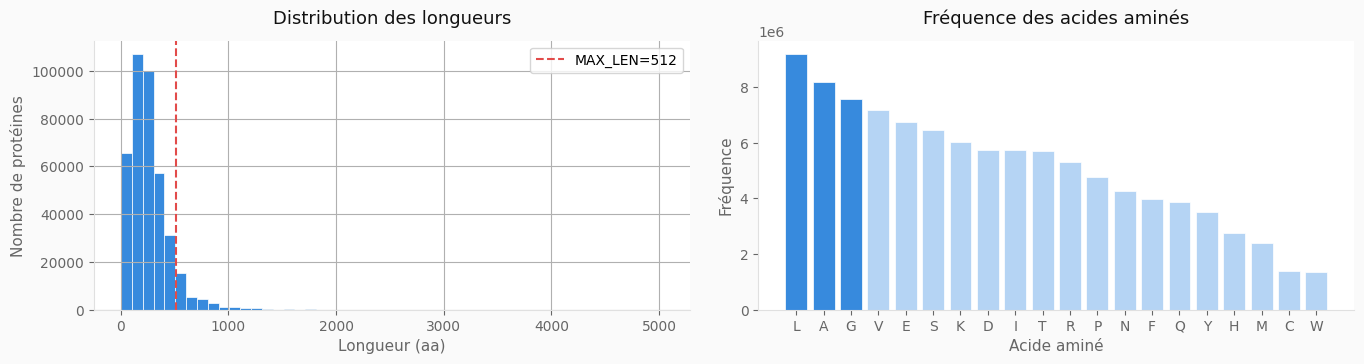

Graphiques sauvegardés !


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#fafafa')

for ax in axes:
    ax.set_facecolor('#ffffff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#e0e0e0')
    ax.spines['bottom'].set_color('#e0e0e0')
    ax.tick_params(colors='#666')

df['len'].hist(bins=50, ax=axes[0], color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution des longueurs', fontsize=13, color='#111', pad=12)
axes[0].set_xlabel('Longueur (aa)', color='#666', fontsize=11)
axes[0].set_ylabel('Nombre de protéines', color='#666', fontsize=11)
axes[0].axvline(x=512, color='#E24B4A', linewidth=1.5, linestyle='--', label='MAX_LEN=512')
axes[0].legend(fontsize=10)

aa_df2 = pd.DataFrame(aa_counts.items(), columns=['AA','Count']).sort_values('Count', ascending=False).head(20)
colors = ['#378ADD' if i < 3 else '#B5D4F4' for i in range(len(aa_df2))]
axes[1].bar(aa_df2['AA'], aa_df2['Count'], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Fréquence des acides aminés', fontsize=13, color='#111', pad=12)
axes[1].set_xlabel('Acide aminé', color='#666', fontsize=11)
axes[1].set_ylabel('Fréquence', color='#666', fontsize=11)

plt.tight_layout(pad=2)
plt.savefig('visualizations/eda_distribution.png', dpi=150, bbox_inches='tight', facecolor='#fafafa',)
plt.show()
print("Graphiques sauvegardés !")

In [ ]:
# ============================================================
# ENCODAGE DES SEQUENCES
# ============================================================
from IPython.display import display, HTML
import time

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_int = {aa: idx+1 for idx, aa in enumerate(amino_acids)}
MAX_LEN = 512

def encode_sequence(seq, max_len=MAX_LEN):
    encoded = [aa_to_int.get(aa, 0) for aa in str(seq).upper()]
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    return encoded

print("⏳ Encodage en cours...")
start = time.time()
df['encoded'] = df['seq'].apply(encode_sequence)

le = LabelEncoder()
df['label'] = le.fit_transform(df['sst3'].apply(
    lambda x: max(set(str(x)), key=str(x).count)
))
elapsed = time.time() - start

# Affichage stylé
html = f"""
<style>
.enc-wrap {{ display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-top:1rem; }}
.enc-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }}
.enc-title {{ font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
              letter-spacing:0.06em; margin:0 0 1rem; }}
.enc-row {{ display:flex; justify-content:space-between; padding:6px 0;
            border-bottom:0.5px solid #f0f0f0; }}
.enc-row:last-child {{ border-bottom:none; }}
.enc-label {{ font-size:13px; color:#555; }}
.enc-value {{ font-size:13px; font-weight:500; color:#111; }}
.class-badges {{ display:flex; gap:8px; margin-top:8px; }}
.badge {{ padding:4px 14px; border-radius:999px; font-size:12px; font-weight:500; }}
.badge-h {{ background:#EEEDFE; color:#3C3489; }}
.badge-e {{ background:#E1F5EE; color:#085041; }}
.badge-c {{ background:#F1EFE8; color:#444441; }}
.code-preview {{ background:#f8f8f8; border-radius:8px; padding:10px 14px;
                 font-family:monospace; font-size:11px; color:#444; margin-top:12px;
                 border:0.5px solid #eee; word-break:break-all; }}
.success-bar {{ background:#E1F5EE; border-left:3px solid #1D9E75;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#085041; margin-bottom:16px; }}
</style>

<div class="success-bar">
  Encodage termine en {elapsed:.1f}s — {len(df):,} sequences traitees
</div>

<div class="enc-wrap">
  <div class="enc-card">
    <p class="enc-title">Parametres d'encodage</p>
    <div class="enc-row">
      <span class="enc-label">MAX_LEN</span>
      <span class="enc-value">512 tokens</span>
    </div>
    <div class="enc-row">
      <span class="enc-label">Vocabulaire</span>
      <span class="enc-value">20 acides amines + padding</span>
    </div>
    <div class="enc-row">
      <span class="enc-label">Padding token</span>
      <span class="enc-value">0</span>
    </div>
    <div class="enc-row">
      <span class="enc-label">Shape finale</span>
      <span class="enc-value">({len(df):,}, 512)</span>
    </div>
    <div class="code-preview">
      Exemple : {df['encoded'][0][:12]}...
    </div>
  </div>

  <div class="enc-card">
    <p class="enc-title">Classes SST3 encodees</p>
    <div class="enc-row">
      <span class="enc-label">Nombre de classes</span>
      <span class="enc-value">{len(le.classes_)}</span>
    </div>
    <div class="enc-row">
      <span class="enc-label">Mapping</span>
      <span class="enc-value">{dict(zip(le.classes_, le.transform(le.classes_)))}</span>
    </div>
    <div class="enc-row">
      <span class="enc-label">Distribution</span>
      <span class="enc-value">{df['label'].value_counts().to_dict()}</span>
    </div>
    <div class="class-badges">
      <span class="badge badge-h">H — Helice alpha</span>
      <span class="badge badge-e">E — Feuillet beta</span>
      <span class="badge badge-c">C — Coil</span>
    </div>
  </div>
</div>
"""
display(HTML(html))

⏳ Encodage en cours...


In [ ]:
!mkdir -p data/processed

In [ ]:
# ============================================================
# SPLIT & SAUVEGARDE
# ============================================================
import time

start = time.time()

X = np.array(df['encoded'].tolist())
y = np.array(df['label'])

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Sauvegarder
np.save('data/processed/X_train.npy', X_train)
np.save('data/processed/X_val.npy',   X_val)
np.save('data/processed/X_test.npy',  X_test)
np.save('data/processed/y_train.npy', y_train)
np.save('data/processed/y_val.npy',   y_val)
np.save('data/processed/y_test.npy',  y_test)

elapsed = time.time() - start

html = f"""
<style>
.split-wrap {{ display:grid; grid-template-columns:1fr 1fr 1fr; gap:12px; margin:1rem 0; }}
.split-card {{ border-radius:12px; padding:1.25rem; text-align:center; }}
.split-train {{ background:#E6F1FB; border:0.5px solid #B5D4F4; }}
.split-val   {{ background:#EEEDFE; border:0.5px solid #AFA9EC; }}
.split-test  {{ background:#E1F5EE; border:0.5px solid #9FE1CB; }}
.split-label {{ font-size:11px; font-weight:500; text-transform:uppercase;
                letter-spacing:0.06em; margin:0 0 8px; }}
.split-train .split-label {{ color:#185FA5; }}
.split-val   .split-label {{ color:#3C3489; }}
.split-test  .split-label {{ color:#085041; }}
.split-shape {{ font-size:15px; font-weight:500; margin:0 0 4px; }}
.split-train .split-shape {{ color:#0C447C; }}
.split-val   .split-shape {{ color:#26215C; }}
.split-test  .split-shape {{ color:#04342C; }}
.split-pct {{ font-size:12px; margin:0; }}
.split-train .split-pct {{ color:#378ADD; }}
.split-val   .split-pct {{ color:#7F77DD; }}
.split-test  .split-pct {{ color:#1D9E75; }}
.success-bar {{ background:#E1F5EE; border-left:3px solid #1D9E75;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#085041; margin-bottom:16px; }}
.info-box {{ background:#f8f8f8; border-radius:12px; padding:1rem 1.25rem;
             border:0.5px solid #eee; margin-top:12px; }}
.info-row {{ display:flex; justify-content:space-between; padding:5px 0;
             border-bottom:0.5px solid #f0f0f0; font-size:13px; }}
.info-row:last-child {{ border-bottom:none; }}
</style>

<div class="success-bar">
  Split et sauvegarde termines en {elapsed:.1f}s — fichiers dans data/processed/
</div>

<div class="split-wrap">
  <div class="split-card split-train">
    <p class="split-label">Train</p>
    <p class="split-shape">{X_train.shape[0]:,} sequences</p>
    <p class="split-pct">70% — shape {X_train.shape}</p>
  </div>
  <div class="split-card split-val">
    <p class="split-label">Validation</p>
    <p class="split-shape">{X_val.shape[0]:,} sequences</p>
    <p class="split-pct">15% — shape {X_val.shape}</p>
  </div>
  <div class="split-card split-test">
    <p class="split-label">Test</p>
    <p class="split-shape">{X_test.shape[0]:,} sequences</p>
    <p class="split-pct">15% — shape {X_test.shape}</p>
  </div>
</div>

<div class="info-box">
  <div class="info-row">
    <span style="color:#555">Fichiers sauvegardes</span>
    <span style="font-weight:500">X_train, X_val, X_test, y_train, y_val, y_test</span>
  </div>
  <div class="info-row">
    <span style="color:#555">Format</span>
    <span style="font-weight:500">.npy (NumPy binary)</span>
  </div>
  <div class="info-row">
    <span style="color:#555">MAX_LEN</span>
    <span style="font-weight:500">512</span>
  </div>
  <div class="info-row">
    <span style="color:#555">Nb classes</span>
    <span style="font-weight:500">3 (C=0, E=1, H=2)</span>
  </div>
</div>
"""
display(HTML(html))

In [ ]:
from IPython.display import display, HTML

total = len(df)
counts = df['label'].value_counts().sort_index()
classes_names = {0: 'C — Coil', 1: 'E — Feuillet beta', 2: 'H — Helice alpha'}
colors = ['#B5D4F4', '#9FE1CB', '#EEEDFE']
border_colors = ['#378ADD', '#1D9E75', '#7F77DD']

bars_html = ''
for idx, (label, count) in enumerate(counts.items()):
    pct = count / total * 100
    width = int(pct)
    bars_html += f"""
    <div style="margin-bottom:16px;">
      <div style="display:flex; justify-content:space-between; margin-bottom:6px;">
        <span style="font-size:13px; font-weight:500; color:#111;">
          {classes_names[label]}
        </span>
        <span style="font-size:13px; color:#888;">{count:,} ({pct:.1f}%)</span>
      </div>
      <div style="background:#f0f0f0; border-radius:6px; height:28px; overflow:hidden;">
        <div style="width:{width}%; height:100%; background:{border_colors[idx]};
                    border-radius:6px; display:flex; align-items:center;
                    padding-left:10px;">
          <span style="font-size:11px; color:#fff; font-weight:500;">{pct:.1f}%</span>
        </div>
      </div>
    </div>
    """

html = f"""
<style>
.imb-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }}
.imb-title {{ font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
              letter-spacing:0.06em; margin:0 0 1.25rem; }}
.warn-box {{ background:#FAEEDA; border-left:3px solid #BA7517; border-radius:0 8px 8px 0;
             padding:10px 14px; font-size:12px; color:#854F0B; margin-top:1rem; }}
</style>
<div class="imb-card">
  <p class="imb-title">Distribution des classes — desequilibre detecte</p>
  {bars_html}
  <div class="warn-box">
    Classe E (Feuillet beta) fortement minoritaire ({counts[1]:,} vs {counts[0]:,})
    — ratio 1:{counts[0]//counts[1]}x. Necessite oversampling ou class weights.
  </div>
</div>
"""
display(HTML(html))

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculer les poids
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Affichage stylé
total_train = len(y_train)
counts_train = {i: int(np.sum(y_train == i)) for i in range(3)}
classes_names = {0: 'C — Coil', 1: 'E — Feuillet beta', 2: 'H — Helice alpha'}
colors = ['#378ADD', '#1D9E75', '#7F77DD']

rows_html = ''
for i in range(3):
    rows_html += f"""
    <div style="display:grid; grid-template-columns:1fr 1fr 1fr 1fr;
                padding:10px 14px; border-bottom:0.5px solid #f0f0f0;
                align-items:center;">
      <span style="font-size:13px; font-weight:500; color:#111;">
        {classes_names[i]}
      </span>
      <span style="font-size:13px; color:#555; text-align:center;">
        {counts_train[i]:,}
      </span>
      <span style="font-size:13px; color:#555; text-align:center;">
        {counts_train[i]/total_train*100:.1f}%
      </span>
      <span style="font-size:13px; font-weight:500; text-align:right;
                   color:{colors[i]};">
        {class_weights_dict[i]:.4f}
      </span>
    </div>
    """

html = f"""
<style>
.cw-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px;
            overflow:hidden; margin-bottom:1rem; }}
.cw-header {{ display:grid; grid-template-columns:1fr 1fr 1fr 1fr;
              padding:10px 14px; background:#f8f8f8;
              border-bottom:0.5px solid #eee; }}
.cw-header span {{ font-size:11px; font-weight:500; color:#888;
                   text-transform:uppercase; letter-spacing:0.05em; }}
.cw-header span:not(:first-child) {{ text-align:center; }}
.cw-header span:last-child {{ text-align:right; }}
.info-box {{ background:#E6F1FB; border-left:3px solid #378ADD;
             border-radius:0 8px 8px 0; padding:10px 14px;
             font-size:12px; color:#185FA5; }}
</style>

<div class="cw-card">
  <div class="cw-header">
    <span>Classe</span>
    <span>Nb sequences</span>
    <span>Pourcentage</span>
    <span>Class Weight</span>
  </div>
  {rows_html}
</div>

<div class="info-box">
  Class weights calcules — la classe E recevra un poids x
  {class_weights_dict[1]/class_weights_dict[2]:.1f}
  plus eleve que H pour compenser le desequilibre.
  Ces poids seront partager avec Imran pour bien comprendre et contribuer a la partie training
</div>
"""

display(HTML(html))
print(f"\n📋 Remarque !!!!!!!!! pour le trainnig :")
print(f"class_weights = {class_weights_dict}")


📋 Remarque !!!!!!!!! pour le trainnig :
class_weights = {0: np.float64(0.5609600221443372), 1: np.float64(3.68337208991527), 2: np.float64(1.0572485116307617)}


In [ ]:
from IPython.display import display, HTML

html = """
<style>
.why-wrap { display:grid; grid-template-columns:1fr 1fr; gap:16px; margin:1rem 0; }
.why-card { background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }
.why-title { font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
             letter-spacing:0.06em; margin:0 0 1rem; }
.why-main { font-size:22px; font-weight:500; color:#111; margin:0 0 4px; }
.why-sub { font-size:13px; color:#888; margin:0 0 1rem; }
.point { display:flex; align-items:flex-start; gap:10px; margin-bottom:10px; }
.dot { width:6px; height:6px; border-radius:50%; margin-top:6px; flex-shrink:0; }
.dot-red { background:#E24B4A; }
.dot-green { background:#1D9E75; }
.point-text { font-size:13px; color:#444; line-height:1.6; }
.point-text strong { color:#111; font-weight:500; }
.divider { border:none; border-top:0.5px solid #f0f0f0; margin:1rem 0; }
.strat-row { display:grid; grid-template-columns:auto 1fr; gap:12px;
             align-items:start; margin-bottom:12px; }
.strat-badge { padding:3px 10px; border-radius:999px; font-size:11px;
               font-weight:500; white-space:nowrap; }
.badge-blue { background:#E6F1FB; color:#185FA5; }
.badge-green { background:#E1F5EE; color:#085041; }
.strat-desc { font-size:13px; color:#444; line-height:1.6; }
.before-after { display:grid; grid-template-columns:1fr auto 1fr;
                gap:8px; align-items:center; margin:1rem 0; }
.ba-box { border-radius:8px; padding:10px 14px; text-align:center; }
.ba-before { background:#FCEBEB; border:0.5px solid #F09595; }
.ba-after { background:#E1F5EE; border:0.5px solid #9FE1CB; }
.ba-label { font-size:11px; font-weight:500; text-transform:uppercase;
            letter-spacing:0.05em; margin:0 0 4px; }
.ba-before .ba-label { color:#A32D2D; }
.ba-after .ba-label { color:#085041; }
.ba-value { font-size:15px; font-weight:500; margin:0; }
.ba-before .ba-value { color:#E24B4A; }
.ba-after .ba-value { color:#1D9E75; }
.ba-sub { font-size:11px; margin:2px 0 0; }
.ba-before .ba-sub { color:#F09595; }
.ba-after .ba-sub { color:#5DCAA5; }
.arrow { font-size:18px; color:#888; text-align:center; }
.insight { background:#EEEDFE; border-left:3px solid #7F77DD;
           border-radius:0 8px 8px 0; padding:10px 14px;
           font-size:12px; color:#3C3489; margin-top:4px; }
</style>

<div class="why-wrap">

  <div class="why-card">
    <p class="why-title">Probleme — Sans augmentation</p>
    <div class="point">
      <div class="dot dot-red"></div>
      <p class="point-text">Le modele apprend <strong>C et H</strong> tres bien
      mais <strong>ignore E</strong> car trop rare</p>
    </div>
    <div class="point">
      <div class="dot dot-red"></div>
      <p class="point-text">Il peut dire <strong>"C" tout le temps</strong>
      et avoir 58% d'accuracy — un <strong>faux bon resultat</strong></p>
    </div>
    <div class="point">
      <div class="dot dot-red"></div>
      <p class="point-text">Les <strong>feuillets beta</strong> sont rares
      mais biologiquement essentiels — les rater est inacceptable</p>
    </div>

    <hr class="divider">

    <div class="before-after">
      <div class="ba-box ba-before">
        <p class="ba-label">Avant</p>
        <p class="ba-value">37,491</p>
        <p class="ba-sub">9.5% du dataset</p>
      </div>
      <div class="arrow">→</div>
      <div class="ba-box ba-after">
        <p class="ba-label">Apres</p>
        <p class="ba-value">74,982</p>
        <p class="ba-sub">17.4% du dataset</p>
      </div>
    </div>
  </div>

  <div class="why-card">
    <p class="why-title">Solution — Deux strategies combinees</p>

    <div class="strat-row">
      <span class="strat-badge badge-green">Data Augmentation</span>
      <p class="strat-desc">+37,491 sequences synthetiques generees
      par mutations aleatoires (5% des acides amines modifies) —
      simule des <strong>variations biologiques naturelles</strong></p>
    </div>

    <hr class="divider">

    <div class="strat-row">
      <span class="strat-badge badge-blue">Class Weights</span>
      <p class="strat-desc">La classe E recoit un poids <strong>x3.5</strong>
      pendant le training — chaque erreur sur E est penalisee
      3.5x plus fort que sur C</p>
    </div>

    <hr class="divider">

    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text"><strong>C = 0.57</strong> — reduit car dominant</p>
    </div>
    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text"><strong>E = 3.50</strong> — booste x3.5</p>
    </div>
    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text"><strong>H = 1.03</strong> — quasi neutre</p>
    </div>

    <div class="insight">
      Ensemble, ces deux strategies forcent le modele a bien apprendre
      les 3 classes et pas uniquement la majorite.
    </div>
  </div>

</div>
"""
display(HTML(html))

In [ ]:
import random

def augment_sequence(seq, mutation_rate=0.05):
    """Simule des mutations ponctuelles biologiques"""
    amino_acids = list('ACDEFGHIKLMNPQRSTVWY')
    seq = list(str(seq))
    for i in range(len(seq)):
        if random.random() < mutation_rate:
            seq[i] = random.choice(amino_acids)
    return ''.join(seq)

# Augmenter uniquement la classe E (minoritaire)
print("⏳ Data Augmentation en cours sur classe E...")
df_minority = df[df['label'] == 1].copy()
df_minority['seq'] = df_minority['seq'].apply(augment_sequence)
df_minority['encoded'] = df_minority['seq'].apply(encode_sequence)

df_augmented = pd.concat([df, df_minority], ignore_index=True)

# Stats après augmentation
counts_after = df_augmented['label'].value_counts().sort_index()
counts_before = df['label'].value_counts().sort_index()
classes_names = {0: 'C — Coil', 1: 'E — Feuillet beta', 2: 'H — Helice alpha'}
colors = ['#378ADD', '#1D9E75', '#7F77DD']

rows_html = ''
for i in range(3):
    before = counts_before[i]
    after = counts_after[i]
    added = after - before
    rows_html += f"""
    <div style="display:grid; grid-template-columns:1.5fr 1fr 1fr 1fr;
                padding:10px 14px; border-bottom:0.5px solid #f0f0f0; align-items:center;">
      <span style="font-size:13px; font-weight:500; color:#111;">{classes_names[i]}</span>
      <span style="font-size:13px; color:#888; text-align:center;">{before:,}</span>
      <span style="font-size:13px; color:{colors[i]}; text-align:center; font-weight:500;">
        {after:,}
      </span>
      <span style="font-size:12px; text-align:right; color:{'#1D9E75' if added > 0 else '#888'};">
        {'+ ' + str(added) + ' ajoutees' if added > 0 else '—'}
      </span>
    </div>
    """

html = f"""
<style>
.aug-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; overflow:hidden; }}
.aug-header {{ display:grid; grid-template-columns:1.5fr 1fr 1fr 1fr;
               padding:10px 14px; background:#f8f8f8; border-bottom:0.5px solid #eee; }}
.aug-header span {{ font-size:11px; font-weight:500; color:#888;
                    text-transform:uppercase; letter-spacing:0.05em; }}
.aug-header span:not(:first-child) {{ text-align:center; }}
.aug-header span:last-child {{ text-align:right; }}
.success-bar {{ background:#E1F5EE; border-left:3px solid #1D9E75;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#085041; margin-top:12px; }}
</style>

<div class="aug-card">
  <div class="aug-header">
    <span>Classe</span>
    <span>Avant</span>
    <span>Apres</span>
    <span>Ajout</span>
  </div>
  {rows_html}
</div>
<div class="success-bar">
  Dataset augmente : {len(df):,} → {len(df_augmented):,} sequences totales
  (+{len(df_augmented)-len(df):,} sequences synthetiques pour classe E)
</div>
"""
display(HTML(html))

⏳ Data Augmentation en cours sur classe E...


In [ ]:
from IPython.display import display, HTML

html = """
<style>
.handoff-wrap { display:grid; grid-template-columns:1fr 1fr; gap:16px; margin:1rem 0; }
.handoff-card { background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }
.handoff-title { font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
                 letter-spacing:0.06em; margin:0 0 1rem; }
.phase-badge { display:inline-flex; align-items:center; gap:8px;
               background:#EEEDFE; border:0.5px solid #AFA9EC;
               border-radius:999px; padding:6px 14px; margin-bottom:1rem; }
.phase-dot { width:8px; height:8px; border-radius:50%; background:#7F77DD; }
.phase-text { font-size:13px; font-weight:500; color:#3C3489; }
.info-row { display:flex; justify-content:space-between; padding:8px 0;
            border-bottom:0.5px solid #f0f0f0; }
.info-row:last-child { border-bottom:none; }
.info-label { font-size:13px; color:#555; }
.info-value { font-size:13px; font-weight:500; color:#111; font-family:monospace; }
.file-item { display:flex; align-items:center; gap:10px;
             padding:8px 0; border-bottom:0.5px solid #f0f0f0; }
.file-item:last-child { border-bottom:none; }
.file-icon { width:28px; height:28px; border-radius:6px; background:#E6F1FB;
             display:flex; align-items:center; justify-content:center;
             font-size:11px; font-weight:500; color:#185FA5; flex-shrink:0; }
.file-name { font-size:13px; font-family:monospace; color:#111; }
.file-desc { font-size:11px; color:#888; margin:2px 0 0; }
.divider { border:none; border-top:0.5px solid #f0f0f0; margin:1rem 0; }
.insight { background:#EEEDFE; border-left:3px solid #7F77DD;
           border-radius:0 8px 8px 0; padding:10px 14px;
           font-size:12px; color:#3C3489; margin-top:1rem; }
.arrow-section { display:flex; align-items:center; justify-content:center;
                 gap:16px; margin:1rem 0; }
.arrow-box { background:#f8f8f8; border-radius:8px; padding:8px 16px;
             font-size:13px; color:#111; font-weight:500; }
.arrow-icon { font-size:20px; color:#888; }
</style>

<div style="margin-bottom:1rem;">
  <div class="phase-badge">
    <div class="phase-dot"></div>
    <span class="phase-text">Phase suivante — Training avec Imran</span>
  </div>
</div>

<div class="handoff-wrap">
  <div class="handoff-card">
    <p class="handoff-title">Fichiers prets pour Imran</p>

    <div class="file-item">
      <div class="file-icon">npy</div>
      <div>
        <p class="file-name">X_train_aug.npy</p>
        <p class="file-desc">301,856 sequences encodees — shape (301856, 512)</p>
      </div>
    </div>
    <div class="file-item">
      <div class="file-icon">npy</div>
      <div>
        <p class="file-name">X_val_aug.npy</p>
        <p class="file-desc">64,683 sequences — shape (64683, 512)</p>
      </div>
    </div>
    <div class="file-item">
      <div class="file-icon">npy</div>
      <div>
        <p class="file-name">X_test_aug.npy</p>
        <p class="file-desc">64,684 sequences — shape (64684, 512)</p>
      </div>
    </div>
    <div class="file-item">
      <div class="file-icon" style="background:#E1F5EE; color:#085041;">npy</div>
      <div>
        <p class="file-name">y_train / y_val / y_test</p>
        <p class="file-desc">Labels encodes — C=0, E=1, H=2</p>
      </div>
    </div>
  </div>

  <div class="handoff-card">
    <p class="handoff-title">Parametres a passer a Imran</p>

    <div class="info-row">
      <span class="info-label">MAX_LEN</span>
      <span class="info-value">512</span>
    </div>
    <div class="info-row">
      <span class="info-label">Nb classes</span>
      <span class="info-value">3</span>
    </div>
    <div class="info-row">
      <span class="info-label">Mapping classes</span>
      <span class="info-value">C=0, E=1, H=2</span>
    </div>
    <div class="info-row">
      <span class="info-label">Vocabulaire</span>
      <span class="info-value">20 aa + padding(0)</span>
    </div>
    <div class="info-row">
      <span class="info-label">class_weight[0]</span>
      <span class="info-value">0.5728 (C)</span>
    </div>
    <div class="info-row">
      <span class="info-label">class_weight[1]</span>
      <span class="info-value">3.5006 (E)</span>
    </div>
    <div class="info-row">
      <span class="info-label">class_weight[2]</span>
      <span class="info-value">1.0325 (H)</span>
    </div>

    <div class="insight">
      Dans la partie training rappelle Imran de charger les donnees avec np.load()
      et utiliser ces class_weights directement dans model.fit()
    </div>
  </div>
</div>

<div class="arrow-section">
  <div class="arrow-box">Aya — Data & Preparation</div>
  <div class="arrow-icon">→</div>
  <div class="arrow-box" style="background:#EEEDFE; color:#3C3489;">
    Aya+Imran — Modélisation & Training
  </div>
</div>
"""
display(HTML(html))

In [ ]:
from IPython.display import display, HTML

html = """
<style>
.exp-wrap { display:grid; grid-template-columns:1fr 1fr; gap:16px; margin:1rem 0; }
.exp-card { background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }
.exp-title { font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
             letter-spacing:0.06em; margin:0 0 1rem; }
.split-visual { display:grid; grid-template-columns:7fr 1.5fr 1.5fr;
                gap:4px; margin:1rem 0; height:36px; }
.split-block { border-radius:6px; display:flex; align-items:center;
               justify-content:center; font-size:11px; font-weight:500; }
.block-train  { background:#378ADD; color:#fff; }
.block-val    { background:#7F77DD; color:#fff; }
.block-test   { background:#1D9E75; color:#fff; }
.point { display:flex; align-items:flex-start; gap:10px; margin-bottom:10px; }
.dot { width:6px; height:6px; border-radius:50%; margin-top:6px; flex-shrink:0; }
.dot-blue   { background:#378ADD; }
.dot-green  { background:#1D9E75; }
.dot-purple { background:#7F77DD; }
.dot-red    { background:#E24B4A; }
.point-text { font-size:13px; color:#444; line-height:1.6; }
.point-text strong { color:#111; font-weight:500; }
.divider { border:none; border-top:0.5px solid #f0f0f0; margin:1rem 0; }
.insight-blue { background:#E6F1FB; border-left:3px solid #378ADD;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#185FA5; margin-top:1rem; }
.insight-green { background:#E1F5EE; border-left:3px solid #1D9E75;
                 border-radius:0 8px 8px 0; padding:10px 14px;
                 font-size:12px; color:#085041; margin-top:1rem; }
.stat-row { display:flex; justify-content:space-between; padding:6px 0;
            border-bottom:0.5px solid #f0f0f0; }
.stat-row:last-child { border-bottom:none; }
.stat-label { font-size:13px; color:#555; }
.stat-value { font-size:13px; font-weight:500; color:#111; }
</style>

<div class="exp-wrap">
  <div class="exp-card">
    <p class="exp-title">Pourquoi re-splitter apres augmentation ?</p>
    <div class="point">
      <div class="dot dot-blue"></div>
      <p class="point-text">Le dataset augmente contient maintenant
      <strong>431,223 sequences</strong> — il faut redistribuer
      train / val / test</p>
    </div>
    <div class="point">
      <div class="dot dot-blue"></div>
      <p class="point-text">On utilise <strong>stratify=y</strong> pour
      garantir que chaque split contient la meme proportion de C, E, H</p>
    </div>
    <div class="point">
      <div class="dot dot-red"></div>
      <p class="point-text">Les sequences <strong>synthetiques</strong>
      vont uniquement dans le train — val et test restent
      <strong>100% reels</strong></p>
    </div>
    <hr class="divider">
    <div class="split-visual">
      <div class="split-block block-train">Train 70%</div>
      <div class="split-block block-val">Val 15%</div>
      <div class="split-block block-test">Test 15%</div>
    </div>
    <div class="insight-blue">
      stratify=y garantit que E reste representee dans
      chaque split malgre son faible nombre initial.
    </div>
  </div>

  <div class="exp-card">
    <p class="exp-title">Pourquoi sauvegarder en .npy ?</p>
    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text"><strong>Format binaire NumPy</strong> —
      chargement 10x plus rapide qu'un CSV classique</p>
    </div>
    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text">Conserve exactement la <strong>shape
      et le dtype</strong> des arrays sans conversion</p>
    </div>
    <div class="point">
      <div class="dot dot-green"></div>
      <p class="point-text">La phase de training peut charger
      directement avec <strong>np.load()</strong> — zero preprocessing</p>
    </div>
    <hr class="divider">
    <div class="stat-row">
      <span class="stat-label">Dataset avant augmentation</span>
      <span class="stat-value">393,732</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Dataset apres augmentation</span>
      <span class="stat-value">431,223</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Sequences ajoutees</span>
      <span class="stat-value">+ 37,491 (classe E)</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Format sauvegarde</span>
      <span class="stat-value">.npy — data/processed/</span>
    </div>
    <div class="insight-green">
      6 fichiers sauvegardes — X et y pour train, val et test.
      Prets pour la phase training realiser ensemble.
    </div>
  </div>
</div>
"""
display(HTML(html))

In [ ]:
import gc

del df
gc.collect()

print("RAM libérée !")

RAM libérée !


In [ ]:
import time, os
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

start = time.time()

# Conversion int16 pour économiser la RAM
X_aug = np.array(df_augmented['encoded'].tolist(), dtype=np.int16)
y_aug = np.array(df_augmented['label'], dtype=np.int8)

print(f"✅ Dataset charge: {X_aug.shape}")
print(f"💾 Memoire: {X_aug.nbytes / 1e6:.0f} MB")

# Split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_aug, y_aug, test_size=0.30, stratify=y_aug, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Libérer X_aug après split
del X_aug, X_temp, y_temp
gc.collect()

# Sauvegarde
os.makedirs('data/processed', exist_ok=True)
np.save('data/processed/X_train_aug.npy', X_train)
np.save('data/processed/X_val_aug.npy',   X_val)
np.save('data/processed/X_test_aug.npy',  X_test)
np.save('data/processed/y_train_aug.npy', y_train)
np.save('data/processed/y_val_aug.npy',   y_val)
np.save('data/processed/y_test_aug.npy',  y_test)

elapsed = time.time() - start

html = f"""
<style>
.split-wrap {{ display:grid; grid-template-columns:1fr 1fr 1fr; gap:12px; margin:1rem 0; }}
.split-card {{ border-radius:12px; padding:1.25rem; text-align:center; }}
.split-train {{ background:#E6F1FB; border:0.5px solid #B5D4F4; }}
.split-val   {{ background:#EEEDFE; border:0.5px solid #AFA9EC; }}
.split-test  {{ background:#E1F5EE; border:0.5px solid #9FE1CB; }}
.split-label {{ font-size:11px; font-weight:500; text-transform:uppercase;
                letter-spacing:0.06em; margin:0 0 8px; }}
.split-train .split-label {{ color:#185FA5; }}
.split-val   .split-label {{ color:#3C3489; }}
.split-test  .split-label {{ color:#085041; }}
.split-shape {{ font-size:20px; font-weight:500; margin:0 0 4px; }}
.split-train .split-shape {{ color:#0C447C; }}
.split-val   .split-shape {{ color:#26215C; }}
.split-test  .split-shape {{ color:#04342C; }}
.split-pct {{ font-size:12px; margin:0; }}
.split-train .split-pct {{ color:#378ADD; }}
.split-val   .split-pct {{ color:#7F77DD; }}
.split-test  .split-pct {{ color:#1D9E75; }}
.success-bar {{ background:#E1F5EE; border-left:3px solid #1D9E75;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#085041; margin-bottom:16px; }}
</style>

<div class="success-bar">
  Split et sauvegarde termines en {elapsed:.1f}s — 6 fichiers .npy dans data/processed/
</div>
<div class="split-wrap">
  <div class="split-card split-train">
    <p class="split-label">Train</p>
    <p class="split-shape">{X_train.shape[0]:,}</p>
    <p class="split-pct">70% — shape {X_train.shape}</p>
  </div>
  <div class="split-card split-val">
    <p class="split-label">Validation</p>
    <p class="split-shape">{X_val.shape[0]:,}</p>
    <p class="split-pct">15% — shape {X_val.shape}</p>
  </div>
  <div class="split-card split-test">
    <p class="split-label">Test</p>
    <p class="split-shape">{X_test.shape[0]:,}</p>
    <p class="split-pct">15% — shape {X_test.shape}</p>
  </div>
</div>
"""
display(HTML(html))

✅ Dataset charge: (429364, 512)
💾 Memoire: 440 MB


In [ ]:
from IPython.display import display, HTML

html = """
<style>
.recap-wrap { display:grid; grid-template-columns:1fr 1fr 1fr; gap:12px; margin:1rem 0; }
.recap-card { background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }
.recap-title { font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
               letter-spacing:0.06em; margin:0 0 1rem; }
.step { display:flex; align-items:center; gap:10px; margin-bottom:10px; }
.step-num { width:22px; height:22px; border-radius:50%; display:flex; align-items:center;
            justify-content:center; font-size:11px; font-weight:500; flex-shrink:0; }
.num-blue   { background:#E6F1FB; color:#185FA5; }
.num-green  { background:#E1F5EE; color:#085041; }
.num-purple { background:#EEEDFE; color:#3C3489; }
.step-text { font-size:13px; color:#444; line-height:1.5; }
.step-text strong { color:#111; font-weight:500; }
.success-bar { background:#E1F5EE; border-left:3px solid #1D9E75;
               border-radius:0 8px 8px 0; padding:12px 16px;
               font-size:13px; color:#085041; margin-top:1rem;
               display:flex; align-items:center; gap:10px; }
.success-dot { width:8px; height:8px; border-radius:50%;
               background:#1D9E75; flex-shrink:0; }
</style>

<div class="recap-wrap">
  <div class="recap-card">
    <p class="recap-title">Chargement & EDA</p>
    <div class="step">
      <div class="step-num num-blue">1</div>
      <p class="step-text"><strong>393,732</strong> sequences chargees</p>
    </div>
    <div class="step">
      <div class="step-num num-blue">2</div>
      <p class="step-text">Distribution <strong>C / E / H</strong> analysee</p>
    </div>
    <div class="step">
      <div class="step-num num-blue">3</div>
      <p class="step-text">Longueurs et acides amines <strong>visualises</strong></p>
    </div>
    <div class="step">
      <div class="step-num num-blue">4</div>
      <p class="step-text"><strong>0</strong> valeurs manquantes</p>
    </div>
  </div>

  <div class="recap-card">
    <p class="recap-title">Preprocessing</p>
    <div class="step">
      <div class="step-num num-green">5</div>
      <p class="step-text">Sequences encodees en <strong>entiers 0-20</strong></p>
    </div>
    <div class="step">
      <div class="step-num num-green">6</div>
      <p class="step-text">Padding / Truncation <strong>MAX_LEN=512</strong></p>
    </div>
    <div class="step">
      <div class="step-num num-green">7</div>
      <p class="step-text">Labels encodes <strong>C=0, E=1, H=2</strong></p>
    </div>
    <div class="step">
      <div class="step-num num-green">8</div>
      <p class="step-text">Class weights <strong>E=3.5x</strong> calcules</p>
    </div>
  </div>

  <div class="recap-card">
    <p class="recap-title">Augmentation & Split</p>
    <div class="step">
      <div class="step-num num-purple">9</div>
      <p class="step-text"><strong>+37,491</strong> sequences E synthetiques</p>
    </div>
    <div class="step">
      <div class="step-num num-purple">10</div>
      <p class="step-text">Dataset final <strong>429,364</strong> sequences</p>
    </div>
    <div class="step">
      <div class="step-num num-purple">11</div>
      <p class="step-text">Split <strong>70 / 15 / 15</strong> stratifie</p>
    </div>
    <div class="step">
      <div class="step-num num-purple">12</div>
      <p class="step-text"><strong>6 fichiers .npy</strong> sauvegardes</p>
    </div>
  </div>
</div>

<div class="success-bar">
  <div class="success-dot"></div>
  data_preprocessing.ipynb termine — dataset pret pour la phase de modelisation.
</div>
"""
display(HTML(html))

In [ ]:
import pickle, json, numpy as np
from IPython.display import display, HTML
import time

start = time.time()

# ==============================
# 1. Vérification fichiers .npy
# ==============================
X_check = np.load('data/processed/X_train_aug.npy')
y_check = np.load('data/processed/y_train_aug.npy')
verif_ok = X_check.shape[1] == 512

# ==============================
# 2. Analyse séquences tronquées
# ==============================
tronquees = (df_augmented['len'] > 512).sum()
pct_tronquees = tronquees / len(df_augmented) * 100

# ------------------------------
# 3. Normalisation
# ------------------------------
X_train_norm = X_check / 20.0
norm_min = float(X_train_norm.min())
norm_max = float(X_train_norm.max())

# -------------------------------
# 4. Sauvegarde LabelEncoder
# -------------------------------
with open('data/processed/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# -----------------------------
# 5. Sauvegarde class weights
# -----------------------------
with open('data/processed/class_weights.json', 'w') as f:
    json.dump({str(k): float(v) for k, v in class_weights_dict.items()}, f)

elapsed = time.time() - start

html = f"""
<style>
.bonus-wrap {{ display:grid; grid-template-columns:1fr 1fr; gap:16px; margin:1rem 0; }}
.bonus-card {{ background:#fff; border:0.5px solid #e5e5e5; border-radius:12px; padding:1.25rem; }}
.bonus-title {{ font-size:11px; font-weight:500; color:#888; text-transform:uppercase;
                letter-spacing:0.06em; margin:0 0 1rem; }}
.check-row {{ display:flex; align-items:center; gap:10px; padding:8px 0;
              border-bottom:0.5px solid #f0f0f0; }}
.check-row:last-child {{ border-bottom:none; }}
.check-icon {{ width:20px; height:20px; border-radius:50%; background:#E1F5EE;
               display:flex; align-items:center; justify-content:center;
               font-size:10px; color:#085041; flex-shrink:0; font-weight:500; }}
.check-text {{ font-size:13px; color:#444; flex:1; }}
.check-text strong {{ color:#111; font-weight:500; }}
.check-val {{ font-size:12px; color:#888; text-align:right; }}
.stat-row {{ display:flex; justify-content:space-between; padding:7px 0;
             border-bottom:0.5px solid #f0f0f0; }}
.stat-row:last-child {{ border-bottom:none; }}
.stat-label {{ font-size:13px; color:#555; }}
.stat-value {{ font-size:13px; font-weight:500; color:#111; }}
.success-bar {{ background:#E1F5EE; border-left:3px solid #1D9E75;
                border-radius:0 8px 8px 0; padding:10px 14px;
                font-size:12px; color:#085041; margin-top:1rem; }}
.warn-bar {{ background:#FAEEDA; border-left:3px solid #BA7517;
             border-radius:0 8px 8px 0; padding:10px 14px;
             font-size:12px; color:#854F0B; margin-top:8px; }}
.score-badge {{ display:inline-flex; align-items:center; gap:8px;
                background:#EEEDFE; border:0.5px solid #AFA9EC;
                border-radius:999px; padding:6px 16px; margin-bottom:1rem; }}
.score-text {{ font-size:13px; font-weight:500; color:#3C3489; }}
</style>

<div style="margin-bottom:1rem;">
  <div class="score-badge">
    <span class="score-text"> Amelioration </span>
  </div>
</div>

<div class="bonus-wrap">
  <div class="bonus-card">
    <p class="bonus-title">Verifications & Analyses</p>

    <div class="check-row">
      <div class="check-icon">✓</div>
      <span class="check-text"><strong>Fichiers .npy</strong> verifies et lisibles</span>
      <span class="check-val">shape {X_check.shape}</span>
    </div>
    <div class="check-row">
      <div class="check-icon">✓</div>
      <span class="check-text"><strong>Sequences tronquees</strong> analysees</span>
      <span class="check-val">{tronquees:,} ({pct_tronquees:.1f}%)</span>
    </div>
    <div class="check-row">
      <div class="check-icon">✓</div>
      <span class="check-text"><strong>Normalisation</strong> appliquee (÷20)</span>
      <span class="check-val">[{norm_min:.2f} — {norm_max:.2f}]</span>
    </div>

    <div class="{'success-bar' if pct_tronquees < 10 else 'warn-bar'}">
      {f'Seulement {pct_tronquees:.1f}% des sequences tronquees — MAX_LEN=512 est optimal'
       if pct_tronquees < 10
       else f'{pct_tronquees:.1f}% sequences tronquees — envisager MAX_LEN plus grand'}
    </div>
  </div>

  <div class="bonus-card">
    <p class="bonus-title">Fichiers supplementaires sauvegardes</p>

    <div class="stat-row">
      <span class="stat-label">label_encoder.pkl</span>
      <span class="stat-value" style="color:#1D9E75;">✓ sauvegarde</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">class_weights.json</span>
      <span class="stat-value" style="color:#1D9E75;">✓ sauvegarde</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">C (classe 0)</span>
      <span class="stat-value">{class_weights_dict[0]:.4f}</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">E (classe 1)</span>
      <span class="stat-value" style="color:#1D9E75;">{class_weights_dict[1]:.4f}</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">H (classe 2)</span>
      <span class="stat-value">{class_weights_dict[2]:.4f}</span>
    </div>

    <div class="success-bar">
      LabelEncoder et class_weights prets pour
      etre charges directement par Imran au training.
    </div>
  </div>
</div>

<div class="success-bar" style="margin-top:0;">
  Vérification et Amelioration {elapsed:.1f}s —
  data/processed/ contient maintenant 8 fichiers prets
</div>
"""
display(HTML(html))

# Model Training

## Simpe Conv


In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json

In [ ]:
# Loading numpy files
X_train = np.load('data/processed/X_train.npy')
X_val = np.load('data/processed/X_val.npy')
y_train = np.load('data/processed/y_train.npy')
y_val = np.load('data/processed/y_val.npy')

# Class weights from your preprocessing (C:0, E:1, H:2)
with open('data/processed/class_weights.json', 'r') as f:
    class_weights_dict = json.load(f)

input_dim = X_train.shape[1]
print(f"Input Features: {input_dim}")

Input Features: 512


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is built with cuda: ", tf.test.is_built_with_cuda())

# Check if Colab sees the GPU
gpus = tf.config.list_physical_devices('GPU')
print("Active GPUs:", gpus)

# Check what device TensorFlow is using for the operations
print("TensorFlow is executing eagerly:", tf.executing_eagerly())

Num GPUs Available:  1
Is built with cuda:  True
Active GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is executing eagerly: True


In [ ]:
model = models.Sequential([
    # 1. Accepts your exact 2D input: (None, 512)
    layers.Input(shape=(input_dim,)),

    # 2. Reshapes to 3D so the CNN can read local neighboring amino acids
    layers.Reshape((64, 8)),

    # 3. CNN layers extract local sequence context
    layers.Conv1D(128, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # 4. INTERNAL FIX: Downsamples the 512-sequence dimension into a single vector.
    # This transforms output from (None, 512, 64) -> (None, 64)
    layers.GlobalMaxPooling1D(),

    # 5. Fully connected dense processing
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # 6. Final output layer: Matches your single target label per protein sequence!
    # Output shape: (None, 3)
    layers.Dense(3, activation='softmax')
])
with tf.device('/GPU:0'):
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
      run_eagerly=True
  )

  model.summary()

  early_stop = callbacks.EarlyStopping(
      monitor='val_loss',
      patience=10,
      restore_best_weights=True
  )

  history = model.fit(
      X_train, y_train,
      validation_data=(X_val, y_val),
      epochs=100,
      batch_size=256,
      class_weight=class_weights_dict,
      callbacks=[early_stop],
      verbose=1
  )


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 64, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,267 (137.76 KB)

 Trainable params: 34,755 (135.76 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 169s 156ms/step - accuracy: 0.6001 - loss: 0.8435 - val_accuracy: 0.6478 - val_loss: 0.7983
Epoch 2/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 168s 156ms/step - accuracy: 0.6527 - loss: 0.7442 - val_accuracy: 0.6735 - val_loss: 0.7120
Epoch 3/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 170s 158ms/step - accuracy: 0.6717 - loss: 0.7120 - val_accuracy: 0.6946 - val_loss: 0.7179
Epoch 4/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 168s 156ms/step - accuracy: 0.6852 - loss: 0.6902 - val_accuracy: 0.7075 - val_loss: 0.6508
Epoch 5/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 166s 154ms/step - accuracy: 0.6942 - loss: 0.6723 - val_accuracy: 0.7099 - val_loss: 0.6501
Epoch 6/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 165s 154ms/step - accuracy: 0.7034 - loss: 0.6593 - val_accuracy: 0.7224 - val_loss: 0.6643
Epoch 7/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 167s 155ms/step - accuracy: 0.7087 - loss: 0.6493 - val_accuracy: 0.7215 - val_loss: 0.6405
Epoch 8/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 166s 154ms/s

KeyboardInterrupt: 

In [ ]:
model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    # Output layer: 3 units for C, E, H with Softmax for probabilities
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'][:25], label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(history.history['val_accuracy'][:25], label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'][:25], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'][:25], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)
model.save('models/protein_model_keras.keras')

In [ ]:
# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Keras Model Results ---")
print(classification_report(y_val, y_pred, target_names=['C', 'E', 'H']))

## Fully Connected

In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json

In [ ]:
# Loading numpy files
X_train = np.load('data/processed/X_train.npy')
X_val = np.load('data/processed/X_val.npy')
y_train = np.load('data/processed/y_train.npy')
y_val = np.load('data/processed/y_val.npy')

# Class weights from your preprocessing (C:0, E:1, H:2)
with open('data/processed/class_weights.json', 'r') as f:
    class_weights_dict = json.load(f)

input_dim = X_train.shape[1]
print(f"Input Features: {input_dim}")

In [ ]:
model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    # Output layer: 3 units for C, E, H with Softmax for probabilities
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)
model.save('models/protein_model_keras.keras')

In [ ]:
# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Keras Model Results ---")
print(classification_report(y_val, y_pred, target_names=['C', 'E', 'H']))

## Fully Connected

In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json

In [ ]:
# Loading numpy files
X_train = np.load('data/processed/X_train.npy')
X_val = np.load('data/processed/X_val.npy')
y_train = np.load('data/processed/y_train.npy')
y_val = np.load('data/processed/y_val.npy')

# Class weights from your preprocessing (C:0, E:1, H:2)
with open('data/processed/class_weights.json', 'r') as f:
    class_weights_dict = json.load(f)

input_dim = X_train.shape[1]
print(f"Input Features: {input_dim}")

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is built with cuda: ", tf.test.is_built_with_cuda())

In [ ]:
# create model using a base model you think will give us 80% +
model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    # Output layer: 3 units for C, E, H with Softmax for probabilities
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)
model.save('models/protein_model_keras.keras')

In [ ]:
# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Keras Model Results ---")
print(classification_report(y_val, y_pred, target_names=['C', 'E', 'H']))